In [3]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import pandas as pd
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'Tesla T4' in torch.cuda.get_device_name(0):
    print("T4 GPU Detected & Optimized. You are ready to go!")
else:
    print(f"Warning: Using {torch.cuda.get_device_name(0)}. If you see errors, switch to T4 GPU.")

T4 GPU Detected & Optimized. You are ready to go!


In [4]:
import os

filename = 'Tweets (1).csv'
path = filename
if not os.path.exists(path):
    for root, dirs, files in os.walk('/kaggle/input'):
        if filename in files:
            path = os.path.join(root, filename)
            break

print(f"Loading data from: {path}")
df = pd.read_csv(path)
df = df.dropna(subset=['text'])
df = df[df['sentiment'].isin(['positive', 'negative'])]
df['label'] = df['sentiment'].map({'negative': 0, 'positive': 1})

df_sampled = df.sample(n=500, random_state=42) if len(df) > 500 else df
texts = df_sampled['text'].astype(str).tolist()
labels = df_sampled['label'].tolist()
print(f"Loaded {len(texts)} tweets for training.")

Loading data from: /kaggle/input/datasets/ayaanvashu/tweets1/Tweets (1).csv
Loaded 500 tweets for training.


In [5]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

encodings = tokenizer(texts, padding=True, truncation=True, return_tensors="pt")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset Class

In [6]:
class SimpleDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = torch.tensor(labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

dataset = SimpleDataset(encodings, labels)
loader = DataLoader(dataset, batch_size=2)

Load Model (with Attention Output)

In [7]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2,
    output_attentions=True
)

model.to(device)


optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning

In [8]:
model.train()
torch.cuda.empty_cache() 
progress_bar = tqdm(loader, desc="Fine-tuning")

for batch in progress_bar:
    optimizer.zero_grad()
    
    
    batch = {k: v.to(device).long() if 'mask' not in k else v.to(device) for k, v in batch.items()}
    
   
    outputs = model(**batch)
    loss = outputs.loss
    
    loss.backward()
    optimizer.step()
    
   
    torch.cuda.synchronize()
    
    progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

Fine-tuning:   0%|          | 0/250 [00:00<?, ?it/s]

Extract Attention Weights

In [12]:
model.eval()
model.to(device)

# Pick a random tweets
sample_text = random.choice(texts)
print(f"Generating Heatmap for: {sample_text}")

inputs = tokenizer(sample_text, return_tensors="pt", truncation=True, padding=True).to(device)
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # tuple of layers

Generating Heatmap for: Hi Charlie, thank you for following me! Nice to know there`s another Ollmann in the new world...


Visualize Attention Heatmap

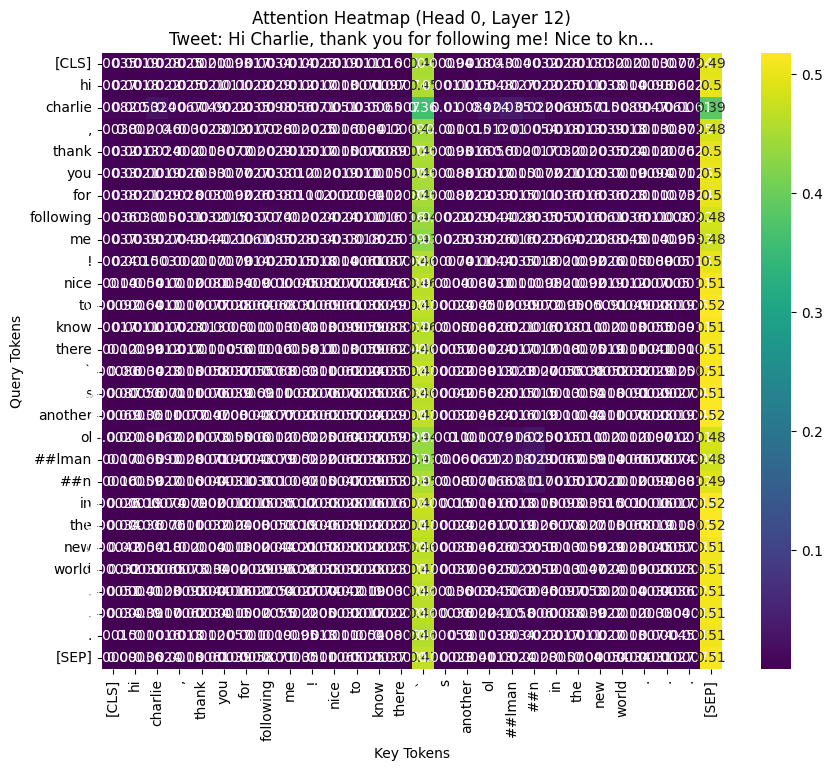

Full Tweet: Hi Charlie, thank you for following me! Nice to know there`s another Ollmann in the new world...


In [13]:
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0].cpu())

attention = attentions[-1][0][0].detach().cpu().numpy()

# Plot the Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(attention, xticklabels=tokens, yticklabels=tokens, annot=True, cmap='viridis')
plt.title(f"Attention Heatmap (Head 0, Layer 12)\nTweet: {sample_text[:50]}...")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()

print(f"Full Tweet: {sample_text}")

PREVIOUS ANALYSIS

Multi-head attention:

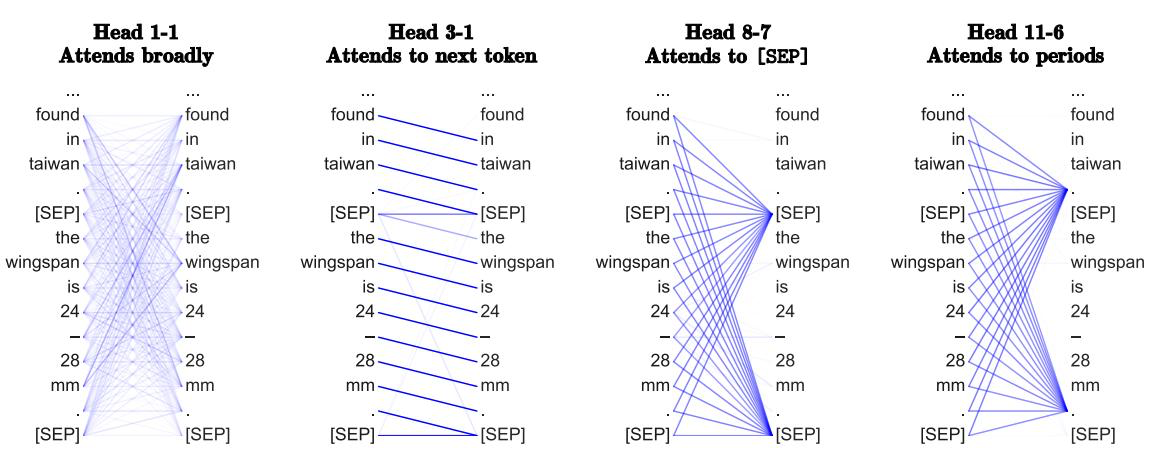

| Head   | What it captures     |
| ------ | -------------------- |
| Head 1 | syntax               |
| Head 2 | sentiment            |
| Head 3 | positional info      |
| Head 4 | long-range relations |


Layer-wise behavior

| Layer         | Role                            |
| ------------- | ------------------------------- |
| Early layers  | local syntax                    |
| Middle layers | phrase structure                |
| Final layers  | task-specific (e.g., sentiment) |

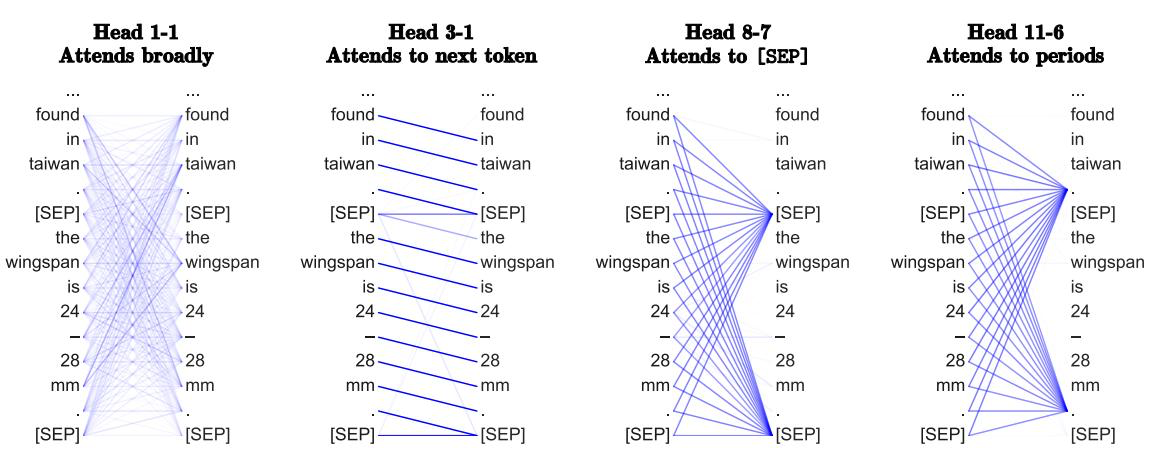